In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

# Resolve project root dynamically
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

warnings.filterwarnings('ignore')

import torch
import gpytorch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

from src.data.data_loader import load_cmapss_data, StreamingCMAPSSDataset
from src.models.train_svgp import train_svgp

In [2]:
# 1. Define paths and features 
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'

# --- THE FIX: DROP CONSTANT SENSORS ---
# Rimuoviamo i sensori identificati nella EDA per sbloccare i gradienti del kernel
dead_sensors = ['s_1', 's_10', 's_18', 's_19']
features = [f's_{i}' for i in range(1, 22) if f's_{i}' not in dead_sensors]
num_features = len(features)
print(f"Using {num_features} informative features.")

# 2. Load Data
df_train = load_cmapss_data(str(DATA_DIR / 'train_FD001.txt'))
df_test = load_cmapss_data(str(DATA_DIR / 'test_FD001.txt'), str(DATA_DIR / 'RUL_FD001.txt'))

# Piecewise Linear RUL Clipping
MAX_RUL = 125
df_train['RUL'] = df_train['RUL'].clip(upper=MAX_RUL)
df_test['RUL'] = df_test['RUL'].clip(upper=MAX_RUL)

# 3. Strict Normalization for FEATURES (X)
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(df_train[features].values)

# 4. Strict Normalization for TARGET (y)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(df_train['RUL'].values.reshape(-1, 1)).flatten()

# 5. Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)

# 6. Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

Using 17 informative features.


In [3]:
# Execute the SVGP training loop
# We use 100 inducing points to compress the dataset representation
model, likelihood = train_svgp(
    train_loader=train_loader, 
    num_features=num_features, 
    num_inducing=256, 
    epochs=100, 
    lr=0.01
)

--- Starting SVGP Training (100 Epochs) ---
Epoch 01/100 - Loss (Negative ELBO): 13.0418
Epoch 02/100 - Loss (Negative ELBO): 2.8862
Epoch 03/100 - Loss (Negative ELBO): 1.2789
Epoch 04/100 - Loss (Negative ELBO): 0.9937
Epoch 05/100 - Loss (Negative ELBO): 0.8954
Epoch 06/100 - Loss (Negative ELBO): 0.8306
Epoch 07/100 - Loss (Negative ELBO): 0.7883
Epoch 08/100 - Loss (Negative ELBO): 0.7531
Epoch 09/100 - Loss (Negative ELBO): 0.7262
Epoch 10/100 - Loss (Negative ELBO): 0.7057
Epoch 11/100 - Loss (Negative ELBO): 0.6879
Epoch 12/100 - Loss (Negative ELBO): 0.6745
Epoch 13/100 - Loss (Negative ELBO): 0.6622
Epoch 14/100 - Loss (Negative ELBO): 0.6517
Epoch 15/100 - Loss (Negative ELBO): 0.6443
Epoch 16/100 - Loss (Negative ELBO): 0.6356
Epoch 17/100 - Loss (Negative ELBO): 0.6313
Epoch 18/100 - Loss (Negative ELBO): 0.6278
Epoch 19/100 - Loss (Negative ELBO): 0.6206
Epoch 20/100 - Loss (Negative ELBO): 0.6199
Epoch 21/100 - Loss (Negative ELBO): 0.6167
Epoch 22/100 - Loss (Negative E

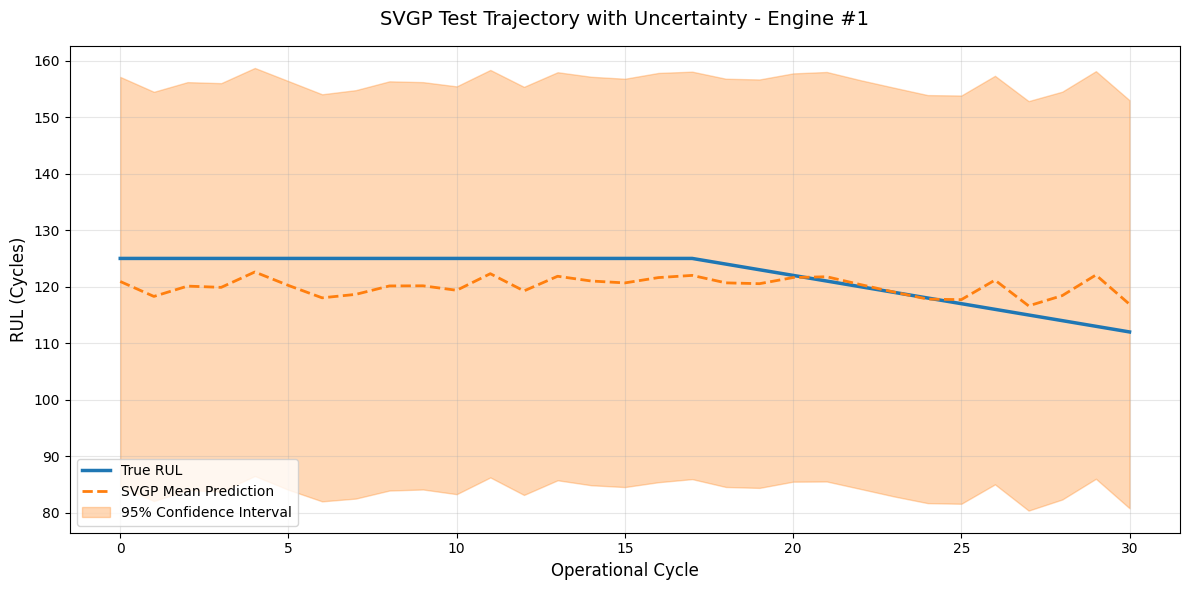

In [4]:
def plot_svgp_predictions_corrected(engine_id=1):
    model.eval()
    likelihood.eval()

    # Extract test data
    engine_data = df_test[df_test['unit_nr'] == engine_id]
    
    # Scale X using the X scaler
    X_test_scaled = scaler_x.transform(engine_data[features].values)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_true = engine_data['RUL'].values

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        observed_pred = likelihood(model(X_test_tensor))
        
        # Extract mean and bounds in SCALED format
        mean_scaled = observed_pred.mean.numpy()
        lower_scaled, upper_scaled = observed_pred.confidence_region()
        lower_scaled = lower_scaled.numpy()
        upper_scaled = upper_scaled.numpy()

    # INVERSE TRANSFORM to get back to original RUL cycles
    mean = scaler_y.inverse_transform(mean_scaled.reshape(-1, 1)).flatten()
    lower = scaler_y.inverse_transform(lower_scaled.reshape(-1, 1)).flatten()
    upper = scaler_y.inverse_transform(upper_scaled.reshape(-1, 1)).flatten()

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(y_true, label="True RUL", color='#1f77b4', linewidth=2.5)
    
    # SVGP Mean and Uncertainty Bands
    plt.plot(mean, label="SVGP Mean Prediction", color='#ff7f0e', linestyle='--', linewidth=2)
    plt.fill_between(range(len(mean)), lower, upper, alpha=0.3, color='#ff7f0e', label="95% Confidence Interval")

    plt.title(f"SVGP Test Trajectory with Uncertainty - Engine #{engine_id}", fontsize=14, pad=15)
    plt.xlabel("Operational Cycle", fontsize=12)
    plt.ylabel("RUL (Cycles)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_svgp_predictions_corrected(engine_id=1)

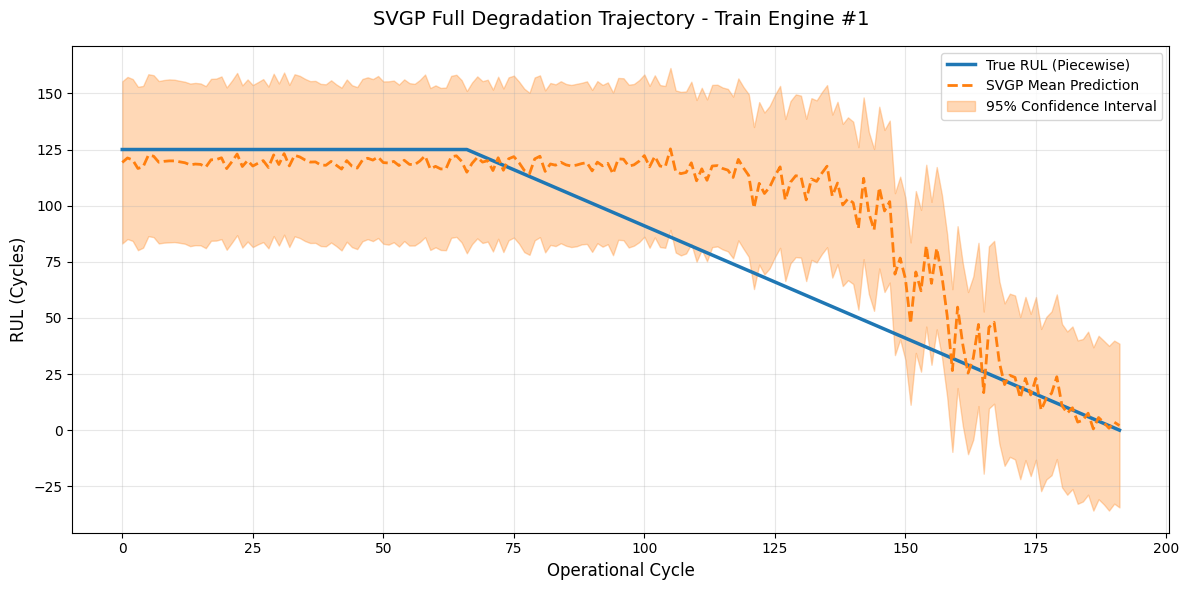

In [5]:
def plot_svgp_full_degradation(engine_id=1):
    model.eval()
    likelihood.eval()

    # Engine data from TRAIN SET to see the full degradation trajectory
    engine_data = df_train[df_train['unit_nr'] == engine_id]
    
    # Scale X using the X scaler
    X_scaled = scaler_x.transform(engine_data[features].values)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    y_true = engine_data['RUL'].values

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        observed_pred = likelihood(model(X_tensor))
        
        # Extract mean and bounds in SCALED format
        mean_scaled = observed_pred.mean.numpy()
        lower_scaled, upper_scaled = observed_pred.confidence_region()
        
    # INVERSE TRANSFORM to get back to original RUL cycles
    mean = scaler_y.inverse_transform(mean_scaled.reshape(-1, 1)).flatten()
    lower = scaler_y.inverse_transform(lower_scaled.reshape(-1, 1)).flatten()
    upper = scaler_y.inverse_transform(upper_scaled.reshape(-1, 1)).flatten()

    # Plotting
    plt.figure(figsize=(12, 6))
    
    # True RUL (clipped at 125)
    plt.plot(y_true, label="True RUL (Piecewise)", color='#1f77b4', linewidth=2.5)
    
    # SVGP Prediction
    plt.plot(mean, label="SVGP Mean Prediction", color='#ff7f0e', linestyle='--', linewidth=2)
    plt.fill_between(range(len(mean)), lower, upper, alpha=0.3, color='#ff7f0e', label="95% Confidence Interval")

    plt.title(f"SVGP Full Degradation Trajectory - Train Engine #{engine_id}", fontsize=14, pad=15)
    plt.xlabel("Operational Cycle", fontsize=12)
    plt.ylabel("RUL (Cycles)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot on engine 1 to see the full degradation trajectory
plot_svgp_full_degradation(engine_id=1)

In [7]:
# ==========================================
# 1. DEFINE THE ONLINE UPDATING FUNCTION
# ==========================================
def update_model_online(model, likelihood, new_X, new_y, update_steps=3, lr=0.01):
    """
    Fine-tunes the SVGP model on a new stream of data.
    Updates only the variational parameters (inducing points) 
    to quickly adjust uncertainty without full retraining.
    """
    model.train()
    likelihood.train()
    
    # Optimize ONLY variational parameters
    optimizer = torch.optim.Adam(model.variational_parameters(), lr=lr)
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=len(new_y))
    
    for i in range(update_steps):
        optimizer.zero_grad()
        output = model(new_X)
        loss = -mll(output, new_y)
        loss.backward()
        optimizer.step()
        
    return model, likelihood

# ==========================================
# 2. PREPARE THE DATA STREAM (ZMIANA TUTAJ!)
# ==========================================
# Use features and scalers defined by Person B in earlier cells
X_test_scaled = scaler_x.transform(df_test[features].values)
y_test_scaled = scaler_y.transform(df_test['RUL'].values.reshape(-1, 1)).flatten()

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

# UŻYWAMY TENSORDATASET ZAMIAST TWOJEJ KLASY, BO DANE SĄ JUŻ TENSORAMI
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

# ==========================================
# 3. ONLINE UPDATING & BUSINESS SIMULATION (WEEK 3)
# ==========================================
threshold_RUL = 30  # Call maintenance when predicted RUL drops below 30 cycles

print("Starting Digital Twin Simulation...")

# Make sure we start with the model in eval mode before the loop
model.eval()
likelihood.eval()

# Data stream simulation:
for batch_idx, (stream_X, stream_y) in enumerate(test_loader):
    
    # 1. Fine-tune the model on the new data batch (Online Update)
    model, likelihood = update_model_online(model, likelihood, stream_X, stream_y, update_steps=3)
    
    # 2. Switch back to eval mode to check predictions
    model.eval()
    likelihood.eval()
    
    with torch.no_grad():
        # Predict outcome (returns values in scaled format)
        predictions = likelihood(model(stream_X))
        
        # Extract mean and confidence bounds (scaled)
        mean_scaled = predictions.mean.numpy()
        lower_scaled, upper_scaled = predictions.confidence_region()
        lower_scaled = lower_scaled.numpy()
        
        # INVERSE TRANSFORM back to real flight cycles
        mean_RUL = scaler_y.inverse_transform(mean_scaled.reshape(-1, 1)).flatten()
        lower_bound = scaler_y.inverse_transform(lower_scaled.reshape(-1, 1)).flatten()
        
        # Check the latest reading in this 10-flight batch:
        current_lower_bound = lower_bound[-1]
        current_mean = mean_RUL[-1]
        
        print(f"Batch {batch_idx}: Mean RUL = {current_mean:.1f} cycles, Lower Bound = {current_lower_bound:.1f} cycles")
        
        # 3. BUSINESS LOGIC
        if current_lower_bound < threshold_RUL:
            print("ALERT: Lower uncertainty bound dropped below the safety threshold!")
            print("Calling maintenance... Stopping machine simulation to prevent failure.")
            break

Starting Digital Twin Simulation...
Batch 0: Mean RUL = 124.5 cycles, Lower Bound = 88.1 cycles
Batch 1: Mean RUL = 122.5 cycles, Lower Bound = 85.5 cycles
Batch 2: Mean RUL = 119.1 cycles, Lower Bound = 81.5 cycles
Batch 3: Mean RUL = 115.2 cycles, Lower Bound = 77.2 cycles
Batch 4: Mean RUL = 119.2 cycles, Lower Bound = 79.7 cycles
Batch 5: Mean RUL = 118.8 cycles, Lower Bound = 77.3 cycles
Batch 6: Mean RUL = 107.6 cycles, Lower Bound = 68.0 cycles
Batch 7: Mean RUL = 113.6 cycles, Lower Bound = 73.2 cycles
Batch 8: Mean RUL = 113.5 cycles, Lower Bound = 73.2 cycles
Batch 9: Mean RUL = 107.2 cycles, Lower Bound = 66.9 cycles
Batch 10: Mean RUL = 93.4 cycles, Lower Bound = 46.4 cycles
Batch 11: Mean RUL = 105.3 cycles, Lower Bound = 61.8 cycles
Batch 12: Mean RUL = 102.7 cycles, Lower Bound = 58.4 cycles
Batch 13: Mean RUL = 110.4 cycles, Lower Bound = 65.1 cycles
Batch 14: Mean RUL = 112.2 cycles, Lower Bound = 72.4 cycles
Batch 15: Mean RUL = 111.9 cycles, Lower Bound = 66.5 cycles